# LMU By-Period Insights

High-level review of by-period team, misc scoring, and player performance.


In [7]:

import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)


## Load data

In [26]:

TEAM_BOX_GLOB = "By Period Data/*_team_boxscore_by_period.csv"
PLAYER_BOX_GLOB = "By Period Data/*_player_boxscore_by_period.csv"
TEAM_MISC_GLOB = "By Period Data/*_team_misc_by_period.csv"

team_box_files = sorted(glob.glob(TEAM_BOX_GLOB))
player_box_files = sorted(glob.glob(PLAYER_BOX_GLOB))
team_misc_files = sorted(glob.glob(TEAM_MISC_GLOB))

team_box = pd.concat([pd.read_csv(f) for f in team_box_files], ignore_index=True)
player_box = pd.concat([pd.read_csv(f) for f in player_box_files], ignore_index=True)
team_misc = pd.concat([pd.read_csv(f) for f in team_misc_files], ignore_index=True)

print("Team box rows:", len(team_box))
print("Player box rows:", len(player_box))
print("Team misc rows:", len(team_misc))


Team box rows: 208
Player box rows: 1821
Team misc rows: 208


In [32]:
period_order = ["Q1","Q2","Q3","Q4","OT1","OT2","OT3","OT4"]
def set_period_cat(df):
    df = df.copy()
    df["period"] = pd.Categorical(df["period"], categories=period_order, ordered=True)
    return df

## Identify LMU team name

Set this if auto-detect fails.

In [27]:

# Try to infer LMU team name from team strings
team_names = sorted(set(team_box['team'].dropna().unique()))
print(team_names)

LMU_TEAM_NAME = None
for t in team_names:
    t_low = t.lower()
    if 'loyola marymount' in t_low or t_low == 'lmu' or t_low.startswith('lmu '):
        LMU_TEAM_NAME = t
        break

LMU_TEAM_NAME


['Cal St. Fullerton', 'Denver', 'Gonzaga', 'Hawaii', 'Idaho St.', 'LMU', 'Nevada', 'Oregon St.', 'Pacific', 'Pepperdine', 'Portland', 'San Diego', 'San Francisco', 'Santa Clara', 'Southern Utah', 'Utah St.', 'Utah Valley', 'Washington St.', 'Weber St.', 'Wichita St.']


'LMU'

If LMU_TEAM_NAME is None, set it manually below.

In [28]:
# LMU_TEAM_NAME = 'Loyola Marymount'
LMU_TEAM_NAME

'LMU'

## Helper filters

In [29]:

# Only period rows (exclude EOG for period-by-period analysis)
period_rows = team_box[team_box['period'].ne('EOG')].copy()
period_misc = team_misc[team_misc['period'].ne('EOG')].copy()
period_players = player_box[player_box['period'].ne('EOG')].copy()

# LMU-only subsets
lmu_team_box = period_rows[period_rows['team'] == LMU_TEAM_NAME].copy()
lmu_misc = period_misc[period_misc['team'] == LMU_TEAM_NAME].copy()
lmu_players = period_players[period_players['team'] == LMU_TEAM_NAME].copy()


## Team scoring + efficiency by quarter

Compute PTS and eFG% by period for LMU.

In [30]:

# Team efficiency by period
lmu_eff = (
    lmu_team_box.groupby('period', as_index=False)
    .agg({
        'PTS': 'mean',
        'FGM': 'mean',
        'FGA': 'mean',
        '3PM': 'mean',
        '3PA': 'mean',
        'FTM': 'mean',
        'FTA': 'mean',
        'TO': 'mean',
    })
)

lmu_eff['eFG%'] = (lmu_eff['FGM'] + 0.5 * lmu_eff['3PM']) / lmu_eff['FGA']
lmu_eff = lmu_eff.round(3)
lmu_eff.sort_values('period')


,period,PTS,FGM,FGA,3PM,3PA,FTM,FTA,TO,eFG%
0,OT1,10.00,2.667,6.333,1.00,3.00,3.667,4.667,1.00,0.500
1,OT2,5.00,2.000,7.000,1.00,6.00,0.000,0.000,2.00,0.357
2,Q1,16.35,6.750,15.200,1.15,3.55,1.700,2.200,2.65,0.482
3,Q2,15.20,5.400,14.800,1.35,4.30,3.050,4.350,3.15,0.410
4,Q3,16.75,6.250,14.100,1.05,3.00,3.200,4.400,2.85,0.480
5,Q4,19.50,6.550,14.550,1.05,3.90,5.350,7.550,3.00,0.486


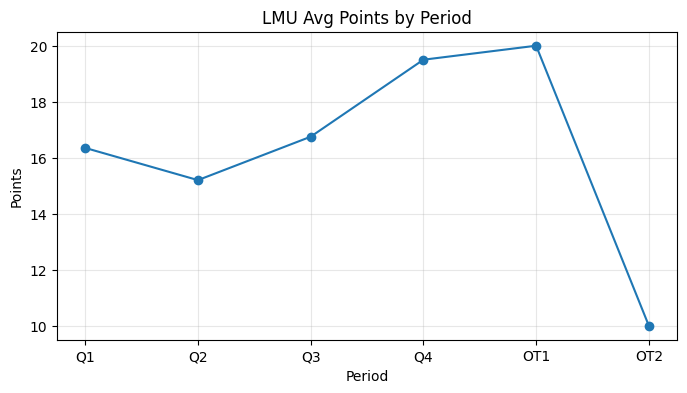

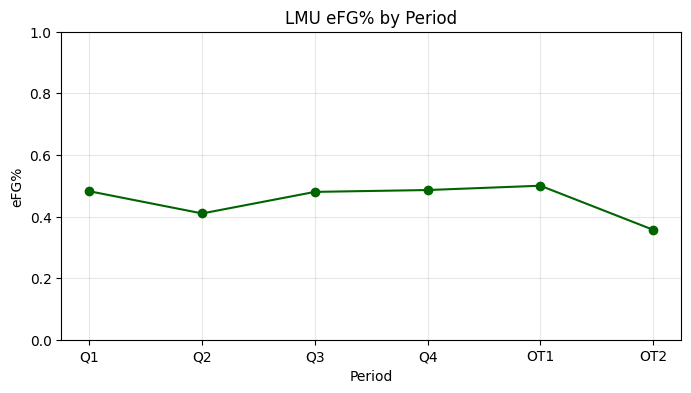

In [31]:
period_order = ['Q1', 'Q2', 'Q3', 'Q4', 'OT1', 'OT2']
lmu_eff['period'] = pd.Categorical(lmu_eff['period'], categories=period_order, ordered=True)
lmu_eff = lmu_eff.sort_values('period')
# Normalize OT1 and OT2 points by multiplying by 2 for fair comparison
ot_mask = lmu_eff['period'].isin(['OT1', 'OT2'])
lmu_eff.loc[ot_mask, 'PTS'] = lmu_eff.loc[ot_mask, 'PTS'] * 2
plt.figure(figsize=(8,4))
plt.plot(lmu_eff['period'], lmu_eff['PTS'], marker='o')
plt.title('LMU Avg Points by Period')
plt.xlabel('Period')
plt.ylabel('Points')
plt.grid(True, alpha=0.3)

plt.show()

plt.figure(figsize=(8,4))
plt.plot(lmu_eff['period'], lmu_eff['eFG%'], marker='o', color='darkgreen')
plt.title('LMU eFG% by Period')
plt.xlabel('Period')
plt.ylabel('eFG%')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()


## Point differential by period (team-level, most important)

Compute LMU minus opponent points for each period in each game, then summarize.

In [38]:

# Build per-game per-period points for both teams
team_pts = period_rows[['game_date', 'team', 'period', 'PTS']].copy()

# For each game+period, pivot teams into columns
pivot = team_pts.pivot_table(index=['game_date','period'], columns='team', values='PTS', aggfunc='sum')

# Determine opponent name each game from available team columns
# LMU differential = LMU - (other team)

def compute_diff(row):
    if LMU_TEAM_NAME not in row.index:
        return np.nan

    # find opponent columns with actual values
    opp_cols = [c for c in row.index if c != LMU_TEAM_NAME and pd.notna(row[c])]
    if len(opp_cols) != 1:
        return np.nan  # safety: should be exactly one opponent in a 2-team game

    opp = opp_cols[0]
    return row[LMU_TEAM_NAME] - row[opp]


pivot['LMU_point_diff'] = pivot.apply(compute_diff, axis=1)

point_diff = (
    pivot.reset_index()
    .groupby('period', as_index=False)['LMU_point_diff']
    .agg(['mean','median','std','count'])
    .reset_index()
)
point_diff = point_diff.round(3)
point_diff.sort_values('period')


,index,period,mean,median,std,count
0,0,OT1,0.667,0.0,4.041,3
1,1,OT2,-7.000,-7.0,NaN,1
2,2,Q1,3.000,2.5,5.822,20
3,3,Q2,-0.150,0.0,4.404,20
4,4,Q3,0.450,0.0,5.306,20
5,5,Q4,0.900,1.5,5.999,20


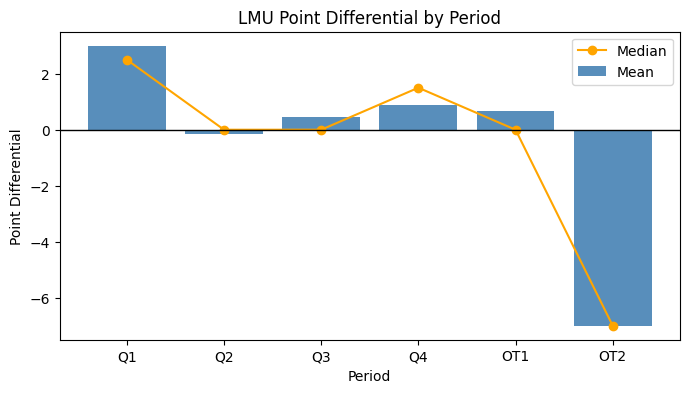

In [41]:

plt.figure(figsize=(8,4))
point_diff = set_period_cat(point_diff)
point_diff = point_diff.sort_values('period')
plt.bar(point_diff['period'], point_diff['mean'], color='steelblue', alpha=0.9, label='Mean')
plt.plot(point_diff['period'], point_diff['median'], color='orange', marker='o', label='Median')
plt.axhline(0, color='black', linewidth=1)
plt.title('LMU Point Differential by Period')
plt.xlabel('Period')
plt.ylabel('Point Differential')
plt.legend()
plt.show()


## Misc scoring by period (LMU)

Mean and median for PTS_POT, PTS_SCP, PTS_FBP, PTS_PIP.

In [42]:

misc_summary = (
    lmu_misc.groupby('period')[['PTS_POT','PTS_SCP','PTS_FBP','PTS_PIP']]
    .agg(['mean','median'])
)

misc_summary


PTS_POT          PTS_SCP          PTS_FBP          PTS_PIP       
          mean median      mean median      mean median      mean median
period                                                                  
OT1       3.00    3.0  0.666667    0.0  1.333333    2.0  3.333333    2.0
OT2       0.00    0.0  0.000000    0.0  0.000000    0.0  2.000000    2.0
Q1        4.85    4.0  2.350000    2.0  2.000000    2.0  8.300000    8.0
Q2        4.20    3.5  3.550000    4.0  1.250000    0.0  7.000000    7.0
Q3        4.50    4.0  2.750000    2.5  1.800000    2.0  7.900000    8.0
Q4        4.05    4.0  4.200000    4.0  2.100000    2.0  8.800000    8.0

/var/folders/qh/zhr4gq8s5px2ff46zwfdk90hy3y30j/T/ipykernel_1518/358149214.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = lmu_misc.groupby('period')[col].mean().reset_index()
/var/folders/qh/zhr4gq8s5px2ff46zwfdk90hy3y30j/T/ipykernel_1518/358149214.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = lmu_misc.groupby('period')[col].mean().reset_index()
/var/folders/qh/zhr4gq8s5px2ff46zwfdk90hy3y30j/T/ipykernel_1518/358149214.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior o

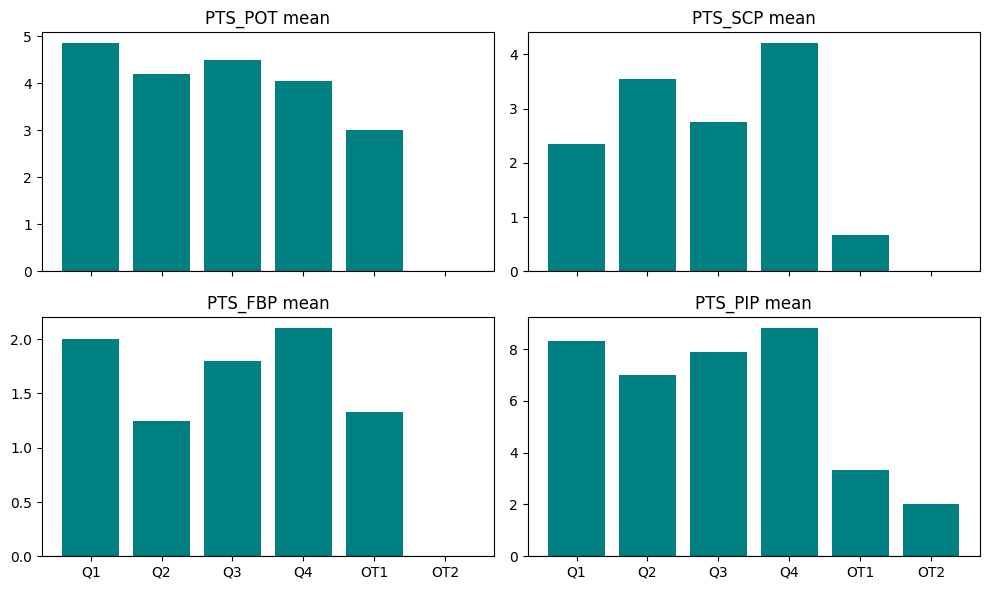

In [44]:

# Quick visualization
fig, ax = plt.subplots(2,2, figsize=(10,6), sharex=True)
cols = ['PTS_POT','PTS_SCP','PTS_FBP','PTS_PIP']
axes = ax.flatten()
lmu_misc = set_period_cat(lmu_misc)
for i, col in enumerate(cols):
    tmp = lmu_misc.groupby('period')[col].mean().reset_index()
    axes[i].bar(tmp['period'], tmp[col], color='teal')
    axes[i].set_title(f'{col} mean')
    axes[i].axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## Top 5 LMU players by PPG (EOG rows) and their by-period efficiency

We use EOG rows to compute PPG, then evaluate per-period performance for those players.

In [45]:

# Compute PPG from EOG rows
lmu_eog_players = player_box[(player_box['team'] == LMU_TEAM_NAME) & (player_box['period'] == 'EOG')].copy()

ppg = (
    lmu_eog_players.groupby('player', as_index=False)
    .agg({'PTS':'mean', 'MIN':'mean'})
    .rename(columns={'PTS':'PPG','MIN':'MPG'})
    .sort_values('PPG', ascending=False)
)

top5 = ppg.head(5)
print(top5)

TOP5_PLAYERS = top5['player'].tolist()


           player    PPG      MPG
9  maya hernandez  15.20  29.3035
5     jess lawson  15.15  30.0240
2   andjela matic   9.60  33.8495
3   carly heidger   8.40  30.9325
4   ivana krajina   5.90  30.3045


In [48]:

# By-period stats for top 5
lmu_top5 = lmu_players[lmu_players['player'].isin(TOP5_PLAYERS)].copy()

player_period = (
    lmu_top5.groupby(['player','period'], as_index=False)
    .agg({
        'PTS':'mean',
        'FGM':'mean',
        'FGA':'mean',
        '3PM':'mean',
        '3PA':'mean',
        'FTM':'mean',
        'FTA':'mean',
        'TO':'mean',
        'MIN':'mean',
    })
)
player_period = player_period.round(3)
player_period = set_period_cat(player_period).sort_values('period')
player_period['eFG%'] = (player_period['FGM'] + 0.5 * player_period['3PM']) / player_period['FGA']

player_period.sort_values(['player','period'])


,player,period,PTS,FGM,FGA,3PM,3PA,FTM,FTA,TO,MIN,eFG%
1,andjela matic,Q1,2.250,0.800,2.250,0.450,1.100,0.200,0.200,0.350,6.936,0.455556
2,andjela matic,Q2,2.900,0.900,2.450,0.650,1.450,0.450,0.500,0.450,8.466,0.500000
3,andjela matic,Q3,1.600,0.650,1.750,0.300,0.800,0.000,0.000,0.350,8.550,0.457143
4,andjela matic,Q4,2.632,0.737,2.368,0.421,1.474,0.737,1.211,0.632,9.162,0.400127
0,andjela matic,OT1,2.333,0.333,2.000,0.333,1.000,1.333,1.333,0.667,4.987,0.249750
7,carly heidger,Q1,2.250,0.950,1.900,0.200,0.600,0.150,0.200,0.300,7.770,0.552632
8,carly heidger,Q2,1.765,0.588,1.882,0.059,0.765,0.529,0.529,0.118,7.761,0.328108
9,carly heidger,Q3,2.526,0.895,1.632,0.316,0.684,0.421,0.474,0.211,7.382,0.645221
10,carly heidger,Q4,1.850,0.600,1.750,0.150,0.700,0.500,0.650,0.200,7.868,0.385714
5,carly heidger,OT1,4.000,1.500,1.500,1.000,1.000,0.000,0.000,0.000,4.915,1.333333


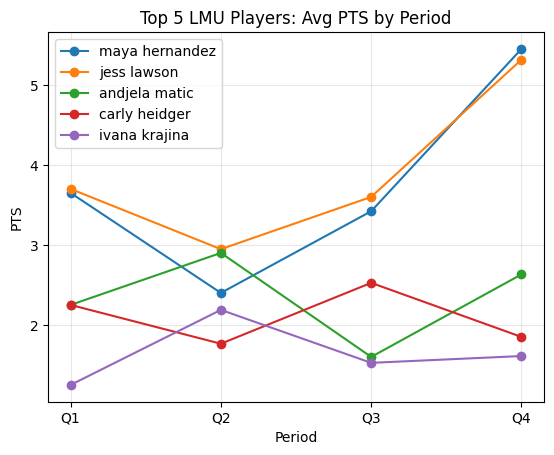

In [53]:

plot_df = player_period.copy()

# Drop OT2 and beyond
plot_df = plot_df[~plot_df["period"].isin(["OT1","OT2","OT3","OT4"])]

# Normalize OT1 to 10 minutes (OT is 5 min → scale by 2)
plot_df["PTS_plot"] = plot_df["PTS"]
plot_df.loc[plot_df["period"] == "OT1", "PTS_plot"] *= 2

period_order = ["Q1","Q2","Q3","Q4"]
plot_df["period"] = pd.Categorical(
    plot_df["period"],
    categories=period_order,
    ordered=True
)
plot_df = plot_df.sort_values("period")


# Plot top 5 PTS by period
for player in TOP5_PLAYERS:
    tmp = plot_df[plot_df['player'] == player]
    plt.plot(tmp['period'], tmp['PTS_plot'], marker='o', label=player)

plt.title('Top 5 LMU Players: Avg PTS by Period')
plt.xlabel('Period')
plt.ylabel('PTS')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


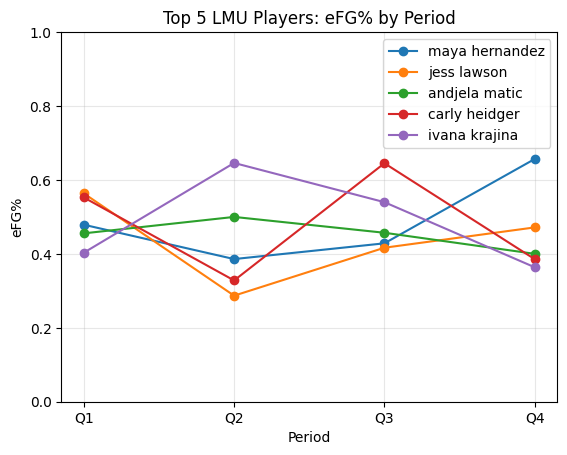

In [54]:

# Plot top 5 eFG% by period
for player in TOP5_PLAYERS:
    tmp = plot_df[plot_df['player'] == player]
    plt.plot(tmp['period'], tmp['eFG%'], marker='o', label=player)

plt.title('Top 5 LMU Players: eFG% by Period')
plt.xlabel('Period')
plt.ylabel('eFG%')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Notes
- If any periods are missing or OT labels appear, check the input CSVs.
- If LMU team name is wrong, set `LMU_TEAM_NAME` manually and re-run.
